# Hospital Readmission Analysis
### Predicting 30-Day Readmission Risk in Diabetic Patients

**Dataset:** UCI "Diabetes 130-US Hospitals" (1999–2008) — 101,766 encounters across 130 US hospitals
**Goal:** Identify the key clinical and administrative factors driving 30-day readmission, and build an interpretable predictive model that could support discharge-planning decisions.

**Pipeline:** Data Cleaning → EDA → Statistical Testing → Feature Engineering → Modeling (Logistic Regression, Random Forest, XGBoost) → Model Explainability (SHAP)

---


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)


## 2. Load Raw Data



In [2]:
raw = pd.read_csv('../data/diabetic_data.csv')
raw = raw.replace('?', np.nan)
print('Raw shape:', raw.shape)
print('Unique patients:', raw['patient_nbr'].nunique(), ' | Encounters:', len(raw))
raw['readmitted'].value_counts(normalize=True).round(3)


Raw shape: (101766, 50)
Unique patients: 71518  | Encounters: 101766


readmitted
NO     0.539
>30    0.349
<30    0.112
Name: proportion, dtype: float64

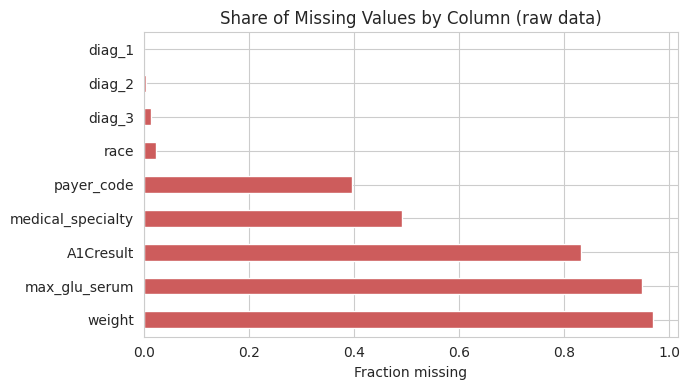

In [3]:
missing = raw.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
missing.plot(kind='barh', color='indianred', figsize=(7,4))
plt.title('Share of Missing Values by Column (raw data)')
plt.xlabel('Fraction missing')
plt.tight_layout()
plt.savefig('../outputs/01_missing_values.png', dpi=120)
plt.show()


## 3. Data Cleaning & Feature Engineering


In [4]:
import sys
sys.path.append('../src')
from clean import load_and_clean, NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET

df = load_and_clean('../data/diabetic_data.csv')
print('Cleaned shape:', df.shape)
print('\nRows removed vs raw:', raw.shape[0] - df.shape[0],
      '(expired/hospice discharges + unknown gender)')
print('\nTarget balance:')
df[TARGET].value_counts(normalize=True).round(3)


Cleaned shape: (99340, 48)

Rows removed vs raw: 2426 (expired/hospice discharges + unknown gender)

Target balance:


readmitted_30d
0    0.886
1    0.114
Name: proportion, dtype: float64

In [5]:
df.head()

,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,diag_1_cat,diag_2_cat,diag_3_cat,readmitted_30d,age_numeric
0,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,41,0,1,0,0,0,1,Not Tested,Not Tested,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Diabetes,Missing,Missing,0,5.0
1,55629189,Caucasian,Female,[10-20),1,1,7,3,Missing,59,0,18,0,0,0,9,Not Tested,Not Tested,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,Endocrine/Metabolic,Diabetes,Endocrine/Metabolic,0,15.0
2,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Missing,11,5,13,2,0,1,6,Not Tested,Not Tested,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,Other,Diabetes,Other/External,0,25.0
3,82442376,Caucasian,Male,[30-40),1,1,7,2,Missing,44,1,16,0,0,0,7,Not Tested,Not Tested,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,Other,Diabetes,Circulatory,0,35.0
4,42519267,Caucasian,Male,[40-50),1,1,7,1,Missing,51,0,8,0,0,0,5,Not Tested,Not Tested,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,Neoplasms,Neoplasms,Diabetes,0,45.0


## 4. Exploratory Data Analysis

### 4.1 Readmission rate by age group

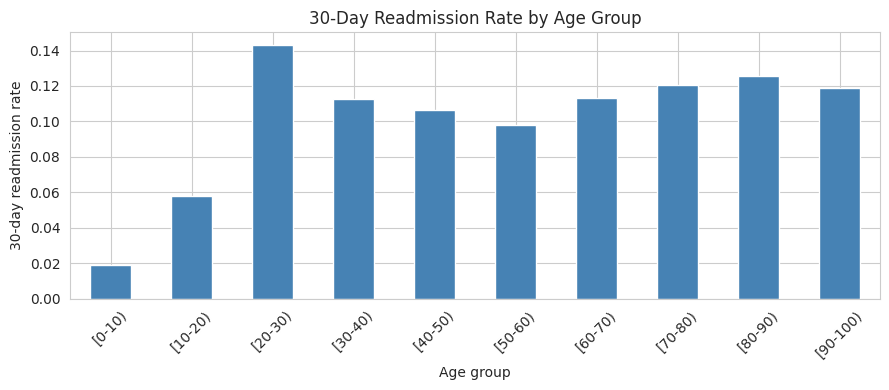

In [6]:
age_readmit = df.groupby('age')['readmitted_30d'].mean().sort_index()
ax = age_readmit.plot(kind='bar', color='steelblue', figsize=(9,4))
plt.ylabel('30-day readmission rate')
plt.xlabel('Age group')
plt.title('30-Day Readmission Rate by Age Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/02_readmission_by_age.png', dpi=120)
plt.show()


### 4.2 Readmission rate by prior inpatient visits

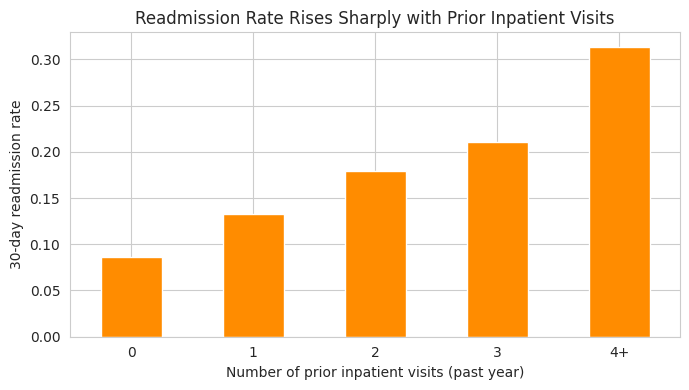

In [7]:
df['prior_inpatient_bucket'] = pd.cut(df['number_inpatient'], bins=[-1,0,1,2,3,100],
                                       labels=['0','1','2','3','4+'])
ax = df.groupby('prior_inpatient_bucket', observed=True)['readmitted_30d'].mean().plot(
    kind='bar', color='darkorange', figsize=(7,4))
plt.ylabel('30-day readmission rate')
plt.xlabel('Number of prior inpatient visits (past year)')
plt.title('Readmission Rate Rises Sharply with Prior Inpatient Visits')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/03_readmission_by_prior_inpatient.png', dpi=120)
plt.show()


### 4.3 Readmission rate by primary diagnosis category

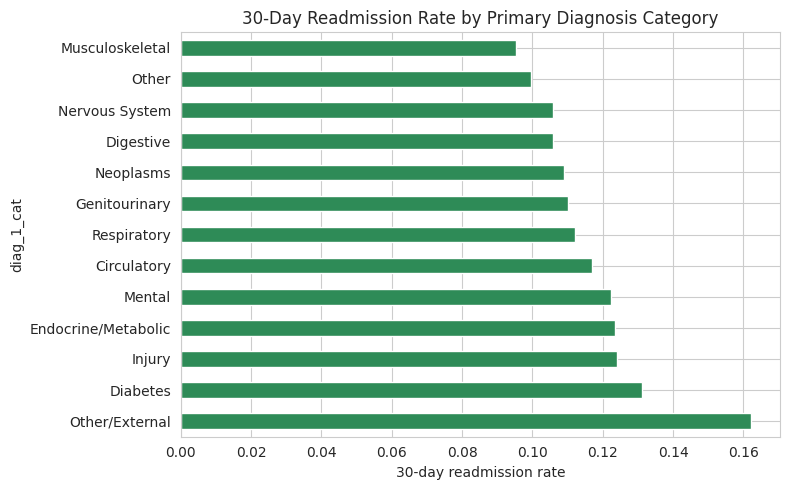

In [8]:
diag_readmit = df.groupby('diag_1_cat')['readmitted_30d'].agg(['mean','count'])
diag_readmit = diag_readmit[diag_readmit['count'] > 200].sort_values('mean', ascending=False)
ax = diag_readmit['mean'].plot(kind='barh', color='seagreen', figsize=(8,5))
plt.xlabel('30-day readmission rate')
plt.title('30-Day Readmission Rate by Primary Diagnosis Category')
plt.tight_layout()
plt.savefig('../outputs/04_readmission_by_diagnosis.png', dpi=120)
plt.show()


### 4.4 Readmission rate by discharge disposition and number of medications

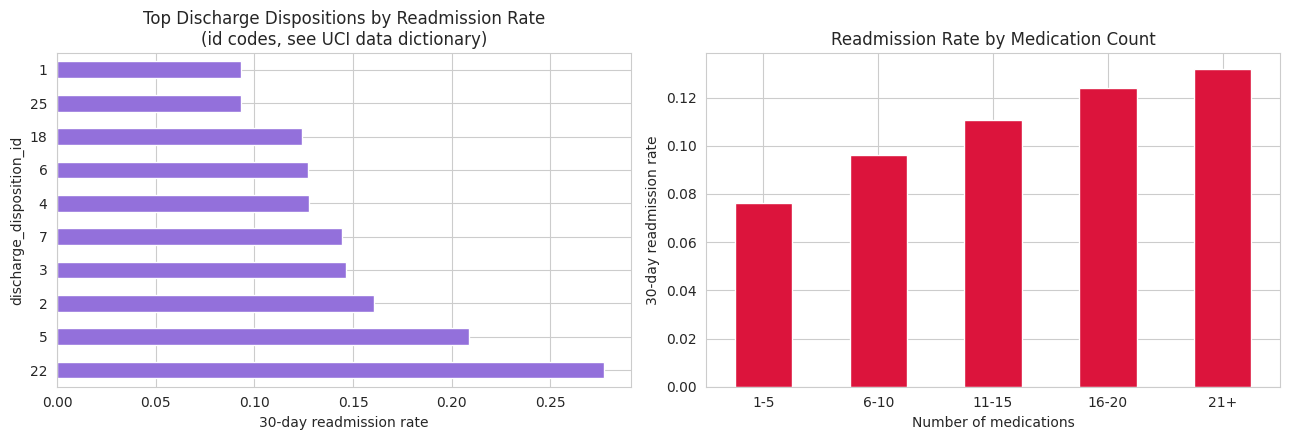

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))

disp_readmit = df.groupby('discharge_disposition_id')['readmitted_30d'].agg(['mean','count'])
disp_readmit = disp_readmit[disp_readmit['count'] > 200].sort_values('mean', ascending=False).head(10)
disp_readmit['mean'].plot(kind='barh', ax=axes[0], color='mediumpurple')
axes[0].set_xlabel('30-day readmission rate')
axes[0].set_title('Top Discharge Dispositions by Readmission Rate\n(id codes, see UCI data dictionary)')

df['med_bucket'] = pd.cut(df['num_medications'], bins=[0,5,10,15,20,100],
                           labels=['1-5','6-10','11-15','16-20','21+'])
df.groupby('med_bucket', observed=True)['readmitted_30d'].mean().plot(
    kind='bar', ax=axes[1], color='crimson')
axes[1].set_xlabel('Number of medications')
axes[1].set_ylabel('30-day readmission rate')
axes[1].set_title('Readmission Rate by Medication Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../outputs/05_discharge_and_medications.png', dpi=120)
plt.show()


### 4.5 Correlation among numeric features

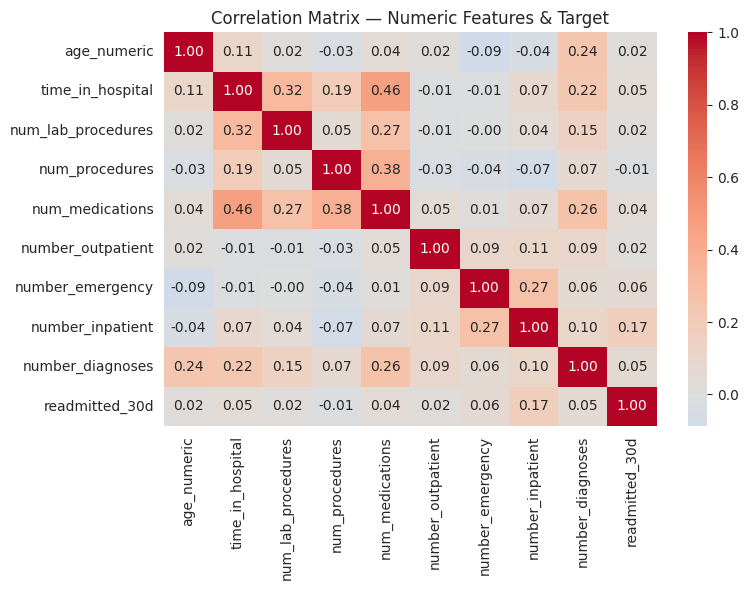

In [10]:
num_cols = NUMERIC_FEATURES + [TARGET]
corr = df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Numeric Features & Target')
plt.tight_layout()
plt.savefig('../outputs/06_correlation_heatmap.png', dpi=120)
plt.show()


## 5. Statistical Testing

Confirming which factors are *statistically* associated with readmission, not just visually different.
- **Chi-square test** for categorical features vs. the binary target
- **Independent t-test** for numeric features (readmitted vs. not readmitted)


In [11]:
print('--- Chi-square tests (categorical features) ---')
chi_results = []
for col in CATEGORICAL_FEATURES:
    contingency = pd.crosstab(df[col], df[TARGET])
    chi2, p, dof, exp = stats.chi2_contingency(contingency)
    chi_results.append((col, chi2, p))

chi_df = pd.DataFrame(chi_results, columns=['feature','chi2','p_value']).sort_values('chi2', ascending=False)
chi_df['significant (p<0.05)'] = chi_df['p_value'] < 0.05
chi_df.reset_index(drop=True)


--- Chi-square tests (categorical features) ---


,feature,chi2,p_value,significant (p<0.05)
0,discharge_disposition_id,1321.902768,6.027940e-268,True
1,medical_specialty,372.961042,3.631641e-42,True
2,insulin,199.219054,6.221589e-43,True
3,diag_3_cat,160.642555,1.461006e-27,True
4,diag_1_cat,135.095206,2.015438e-22,True
5,diag_2_cat,76.706124,4.574199e-11,True
6,diabetesMed,66.753345,3.076948e-16,True
7,admission_source_id,59.913368,5.412572e-07,True
8,A1Cresult,42.576724,3.026712e-09,True
9,change,34.150559,5.100859e-09,True


In [12]:
print('--- T-tests (numeric features) ---')
t_results = []
readmit_yes = df[df[TARGET]==1]
readmit_no = df[df[TARGET]==0]
for col in NUMERIC_FEATURES:
    t, p = stats.ttest_ind(readmit_yes[col], readmit_no[col], equal_var=False)
    t_results.append((col, readmit_yes[col].mean(), readmit_no[col].mean(), t, p))

t_df = pd.DataFrame(t_results, columns=['feature','mean_if_readmitted','mean_if_not','t_stat','p_value'])
t_df['significant (p<0.05)'] = t_df['p_value'] < 0.05
t_df.sort_values('p_value').reset_index(drop=True)


--- T-tests (numeric features) ---


,feature,mean_if_readmitted,mean_if_not,t_stat,p_value,significant (p<0.05)
0,number_inpatient,1.222733,0.554893,35.583828,4.868421e-264,True
1,number_diagnoses,7.691798,7.364472,18.241688,1.486380e-73,True
2,time_in_hospital,4.767545,4.329471,14.525306,1.830616e-47,True
3,number_emergency,0.357698,0.177982,13.588364,9.294381e-42,True
4,num_medications,16.908874,15.859541,12.976182,2.740433e-38,True
5,num_lab_procedures,44.222114,42.738191,7.692733,1.532706e-14,True
6,age_numeric,66.731483,65.617204,7.056683,1.782866e-12,True
7,number_outpatient,0.436892,0.360564,5.898212,3.758251e-09,True
8,num_procedures,1.282747,1.340808,-3.533578,4.112353e-04,True


## 6. Predictive Modeling



In [13]:
sys.path.append('../src')
from model import get_data, train_test, build_preprocessor, evaluate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
import xgboost as xgb

X, y, df_full = get_data('../data/diabetic_data.csv')
X_train, X_test, y_train, y_test = train_test(X, y)
preprocessor = build_preprocessor()
print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Train positive rate: %.3f | Test positive rate: %.3f' % (y_train.mean(), y_test.mean()))


Train: (79472, 23)  Test: (19868, 23)
Train positive rate: 0.114 | Test positive rate: 0.114


In [14]:
# Logistic Regression (interpretable baseline)
logreg_pipe = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42)),
])
logreg_pipe.fit(X_train, y_train)
res_logreg = evaluate('Logistic Regression (+SMOTE)', logreg_pipe, X_test, y_test)



Logistic Regression (+SMOTE)
AUC-ROC: 0.6524
              precision    recall  f1-score   support

           0      0.921     0.664     0.771     17605
           1      0.176     0.557     0.267      2263

    accuracy                          0.652     19868
   macro avg      0.548     0.610     0.519     19868
weighted avg      0.836     0.652     0.714     19868



In [15]:
# Random Forest
rf_pipe = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=300, max_depth=10,
                                    class_weight='balanced', random_state=42, n_jobs=-1)),
])
rf_pipe.fit(X_train, y_train)
res_rf = evaluate('Random Forest (+SMOTE)', rf_pipe, X_test, y_test)



Random Forest (+SMOTE)
AUC-ROC: 0.6444
              precision    recall  f1-score   support

           0      0.897     0.911     0.904     17605
           1      0.215     0.189     0.201      2263

    accuracy                          0.829     19868
   macro avg      0.556     0.550     0.553     19868
weighted avg      0.820     0.829     0.824     19868



In [16]:
# XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, eval_metric='auc',
        random_state=42, n_jobs=-1
    )),
])
xgb_pipe.fit(X_train, y_train)
res_xgb = evaluate('XGBoost (class-weighted)', xgb_pipe, X_test, y_test)



XGBoost (class-weighted)
AUC-ROC: 0.6740
              precision    recall  f1-score   support

           0      0.926     0.674     0.780     17605
           1      0.186     0.579     0.281      2263

    accuracy                          0.663     19868
   macro avg      0.556     0.626     0.530     19868
weighted avg      0.841     0.663     0.723     19868



### 6.1 Model comparison

,Model,AUC-ROC
2,XGBoost (class-weighted),0.6740
0,Logistic Regression (+SMOTE),0.6524
1,Random Forest (+SMOTE),0.6444


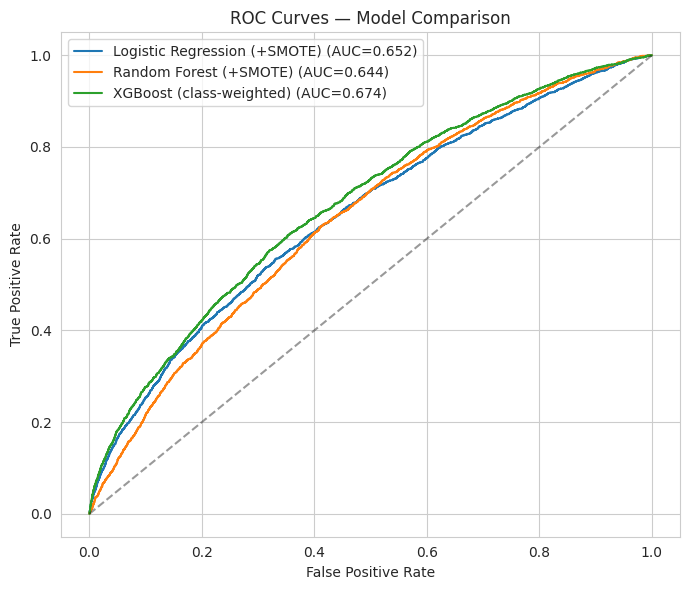

In [17]:
from sklearn.metrics import roc_curve

results = [res_logreg, res_rf, res_xgb]
summary = pd.DataFrame([{'Model': r['name'], 'AUC-ROC': round(r['auc'],4)} for r in results])
display(summary.sort_values('AUC-ROC', ascending=False))

plt.figure(figsize=(7,6))
for r in results:
    fpr, tpr, _ = roc_curve(y_test, r['proba'])
    plt.plot(fpr, tpr, label=f"{r['name']} (AUC={r['auc']:.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/07_roc_comparison.png', dpi=120)
plt.show()


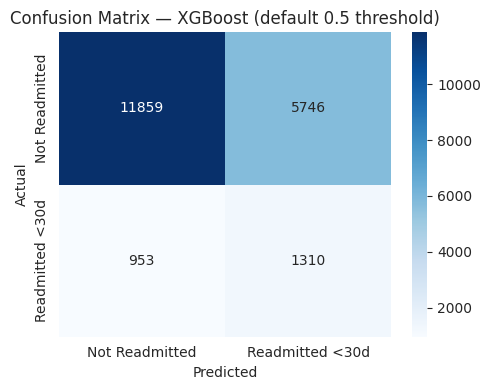

In [18]:
cm = confusion_matrix(y_test, res_xgb['preds'])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Readmitted','Readmitted <30d'],
            yticklabels=['Not Readmitted','Readmitted <30d'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix — XGBoost (default 0.5 threshold)')
plt.tight_layout()
plt.savefig('../outputs/08_confusion_matrix.png', dpi=120)
plt.show()


## 7. Model Explainability (SHAP)

In [19]:
import shap

# SHAP on XGBoost's native booster for speed; transform a sample of the test set
X_test_transformed = xgb_pipe.named_steps['preprocess'].transform(X_test)
feature_names = xgb_pipe.named_steps['preprocess'].get_feature_names_out()

sample_idx = np.random.RandomState(42).choice(X_test_transformed.shape[0], size=2000, replace=False)
X_sample = X_test_transformed[sample_idx]

explainer = shap.TreeExplainer(xgb_pipe.named_steps['clf'])
shap_values = explainer.shap_values(X_sample)


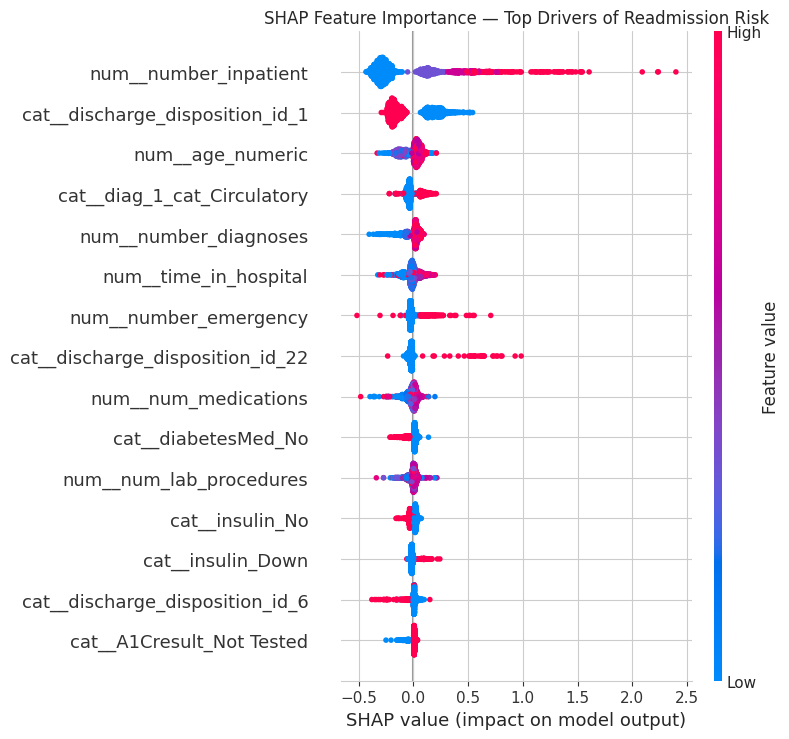

In [20]:
plt.figure()
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False, max_display=15)
plt.title('SHAP Feature Importance — Top Drivers of Readmission Risk')
plt.tight_layout()
plt.savefig('../outputs/09_shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()


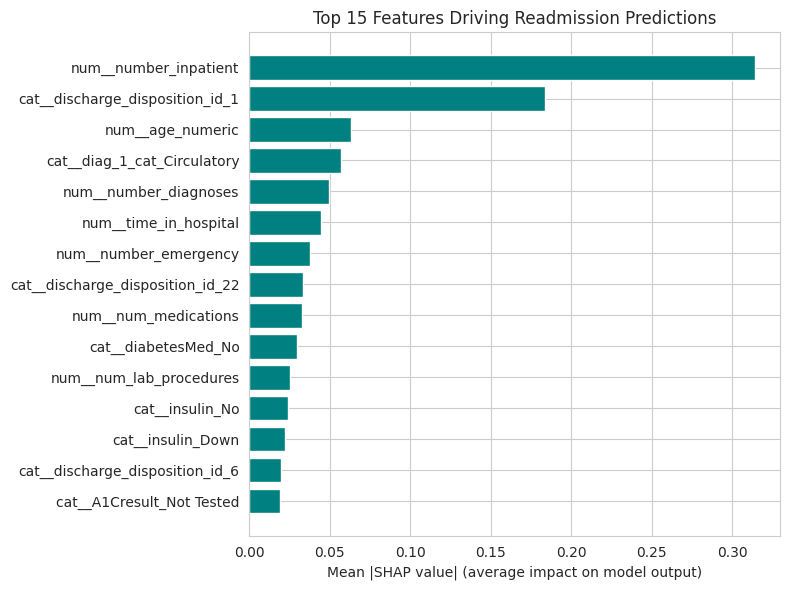

In [21]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_abs_shap})
importance_df = importance_df.sort_values('mean_abs_shap', ascending=False).head(15)

plt.figure(figsize=(8,6))
plt.barh(importance_df['feature'][::-1], importance_df['mean_abs_shap'][::-1], color='teal')
plt.xlabel('Mean |SHAP value| (average impact on model output)')
plt.title('Top 15 Features Driving Readmission Predictions')
plt.tight_layout()
plt.savefig('../outputs/10_shap_bar.png', dpi=120)
plt.show()
